In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler
import joblib
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)


In [2]:
df = pd.read_csv(
    "../datasets/processed/climate_profiles.csv"
)
print("Dataset Loaded Successfully")
print("Shape:", df.shape)


Dataset Loaded Successfully
Shape: (119398, 146)


In [3]:
anomaly_features = [
    "temperature_celsius",
    "humidity",
    "pressure_mb",
    "precip_mm",
    "cloud",
    "uv_index",
    "visibility_km",
    "air_quality_PM2.5",
    "air_quality_PM10",
    "air_quality_Carbon_Monoxide",
    "air_quality_Ozone",
    "air_quality_Nitrogen_dioxide",
    "air_quality_Sulphur_dioxide",
    "day_length_minutes",
    "temperature_gap"
]
X = df[anomaly_features]
print(X.shape)


(119398, 15)


In [4]:
anomaly_scaler = RobustScaler()
X_scaled = anomaly_scaler.fit_transform(X)
print(X_scaled.shape)


(119398, 15)


In [5]:
joblib.dump(
    anomaly_scaler,
    "../models/anomaly_scaler.pkl"
)
print("Anomaly scaler saved")


Anomaly scaler saved


In [6]:
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.01,
    random_state=42,
    n_jobs=-1
)
iso_forest.fit(X_scaled)
print("Isolation Forest trained")


Isolation Forest trained


In [7]:
df["anomaly_flag"] = iso_forest.predict(X_scaled)
df["anomaly_flag"].value_counts()


C:\Users\user\AppData\Local\Temp\ipykernel_8640\1893148315.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["anomaly_flag"] = iso_forest.predict(X_scaled)


anomaly_flag
 1    118204
-1      1194
Name: count, dtype: int64

In [8]:
df["anomaly_status"] = df["anomaly_flag"].map({
    1: "Normal",
   -1: "Anomaly"
})
df["anomaly_status"].value_counts()


C:\Users\user\AppData\Local\Temp\ipykernel_8640\519671752.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["anomaly_status"] = df["anomaly_flag"].map({


anomaly_status
Normal     118204
Anomaly      1194
Name: count, dtype: int64

In [9]:
anomaly_percent = (
    (df["anomaly_flag"] == -1).mean()
    * 100
)
print(
    f"Anomaly Percentage: {anomaly_percent:.2f}%"
)


Anomaly Percentage: 1.00%


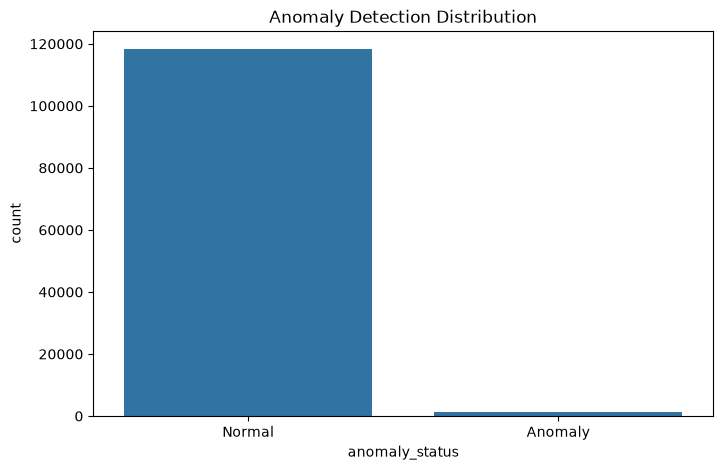

In [10]:
plt.figure(figsize=(8,5))
sns.countplot(
    x="anomaly_status",
    data=df
)
plt.title(
    "Anomaly Detection Distribution"
)
plt.show()


In [11]:
anomalies = df[
    df["anomaly_flag"] == -1
]
print("Anomalies Found:")
print(anomalies.shape)
anomalies[
    anomaly_features
].describe()


Anomalies Found:
(1194, 148)


,temperature_celsius,humidity,pressure_mb,precip_mm,cloud,uv_index,visibility_km,air_quality_PM2.5,air_quality_PM10,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,day_length_minutes,temperature_gap
count,1194.000000,1194.000000,1194.000000,1194.000000,1194.000000,1194.000000,1194.000000,1194.000000,1194.000000,1194.000000,1194.000000,1194.000000,1194.000000,1194.000000,1194.000000
mean,20.615913,75.404523,1013.167504,0.431633,30.007538,1.525963,3.851508,442.977554,537.257873,4418.091374,12.754104,92.059129,71.816164,681.622278,1.276968
std,7.153446,19.050417,5.509916,2.649379,32.232248,1.638211,3.157660,226.934965,266.321903,2340.901365,32.722186,53.284980,68.286496,44.756907,2.066809
min,-3.100000,16.000000,998.000000,0.000000,0.000000,1.000000,0.000000,1.200000,1.400000,148.500000,0.000000,0.300000,0.000000,605.000000,-5.900000
25%,15.000000,62.000000,1010.000000,0.000000,0.000000,1.000000,2.000000,290.175000,367.375000,2910.600000,0.000000,54.975000,28.950000,646.250000,0.000000
50%,22.000000,82.000000,1014.000000,0.000000,25.000000,1.000000,2.800000,449.700000,548.350000,4112.200000,0.000000,86.400000,56.300000,675.000000,0.400000
75%,27.000000,89.000000,1017.000000,0.000000,50.000000,1.000000,3.500000,580.500000,702.200000,5714.400000,9.275000,117.900000,89.700000,720.000000,2.400000
max,35.800000,100.000000,1025.000000,43.800000,100.000000,9.000000,10.000000,1374.800000,1537.800000,13565.100000,243.200000,318.100000,557.000000,775.000000,8.400000


In [12]:
pd.crosstab(
    df["climate_profile"],
    df["anomaly_status"],
    margins=True
)


anomaly_status,Anomaly,Normal,All
climate_profile,,,
Extreme-Pollution,790,584,1374
Flood-Prone,254,22205,22459
Moderate,43,76360,76403
Pollution-Prone,107,19055,19162
All,1194,118204,119398


In [13]:
joblib.dump(
    iso_forest,
    "../models/isolation_forest.pkl"
)
print("Isolation Forest model saved")


Isolation Forest model saved


In [14]:
df.to_csv(
    "../datasets/processed/climate_anomalies.csv",
    index=False
)
print(
    "Dataset saved successfully"
)


Dataset saved successfully


In [15]:
saved_df = pd.read_csv(
    "../datasets/processed/climate_anomalies.csv"
)
print(saved_df.shape)
print(
    saved_df["anomaly_status"]
    .value_counts()
)


(119398, 148)
anomaly_status
Normal     118204
Anomaly      1194
Name: count, dtype: int64


In [16]:
print("""
ANOMALY DETECTION REPORT

Algorithm:
Isolation Forest

Features Used:
15 Climate Features

Contamination:
1%

Outputs:
Normal
Anomaly

Artifacts Saved:
anomaly_scaler.pkl
isolation_forest.pkl
climate_anomalies.csv

Completed Successfully
""")



ANOMALY DETECTION REPORT

Algorithm:
Isolation Forest

Features Used:
15 Climate Features

Contamination:
1%

Outputs:
Normal
Anomaly

Artifacts Saved:
anomaly_scaler.pkl
isolation_forest.pkl
climate_anomalies.csv

Completed Successfully



Example

In [17]:
for c in [0.005,0.01,0.02,0.03]:
    model = IsolationForest(
        contamination=c,
        random_state=42
    )

    preds = model.fit_predict(X_scaled)

    print(c, np.sum(preds==-1))




0.005 597
0.01 1194
0.02 2388
0.03 3582


In [18]:
df["anomaly_score"] = iso_forest.decision_function(X_scaled)

C:\Users\user\AppData\Local\Temp\ipykernel_8640\2928307817.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["anomaly_score"] = iso_forest.decision_function(X_scaled)
